<a href="https://colab.research.google.com/github/saiteja-hash/Ai_enbaled_systems/blob/main/Group%20project%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1: Dataset loading and Cleaning

In [1]:
# modules
!pip install ucimlrepo
!pip install scikit-surprise pandas
import pandas as pd
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import SVD, dataset, Reader, accuracy
from surprise.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 10.2 MB/s eta 0:00:00


In [2]:
#loading Dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

In [3]:
# Combining data
df = pd.concat([X, y], axis=1)

In [4]:
# Displaying rows
display(df.head())

# Displaying shape
print("Shape:", df.shape)

# Displaying details
df.info()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [5]:

# Displaying summary
df.describe(include="all")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [6]:
# Counting missing values
df.isnull().sum()



,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# Displaying data types
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object


In [9]:
df["heart_disease"] = (df["num"] > 0).astype(int)

#  Section 2: EDA

In [10]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

### 1. Target Variable Analysis

/tmp/ipykernel_2894/356069278.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='heart_disease', palette='Set1')


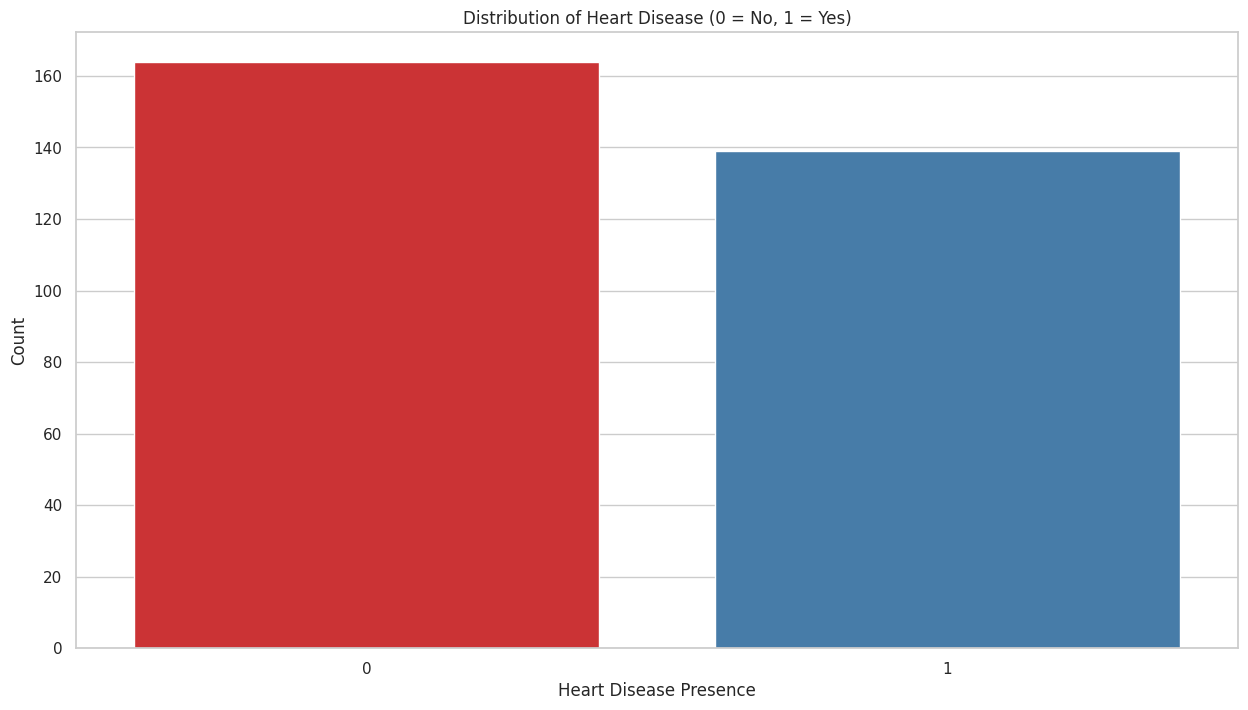

heart_disease
0    54.125413
1    45.874587
Name: proportion, dtype: float64


In [11]:
# Check the distribution of the target variable distribution and check for any class imbalances

sns.countplot(data=df, x='heart_disease', palette='Set1')
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')
plt.xlabel('Heart Disease Presence')
plt.ylabel('Count')
plt.show()

print(df['heart_disease'].value_counts(normalize=True) * 100)


### 2. Categorical Features Analysis

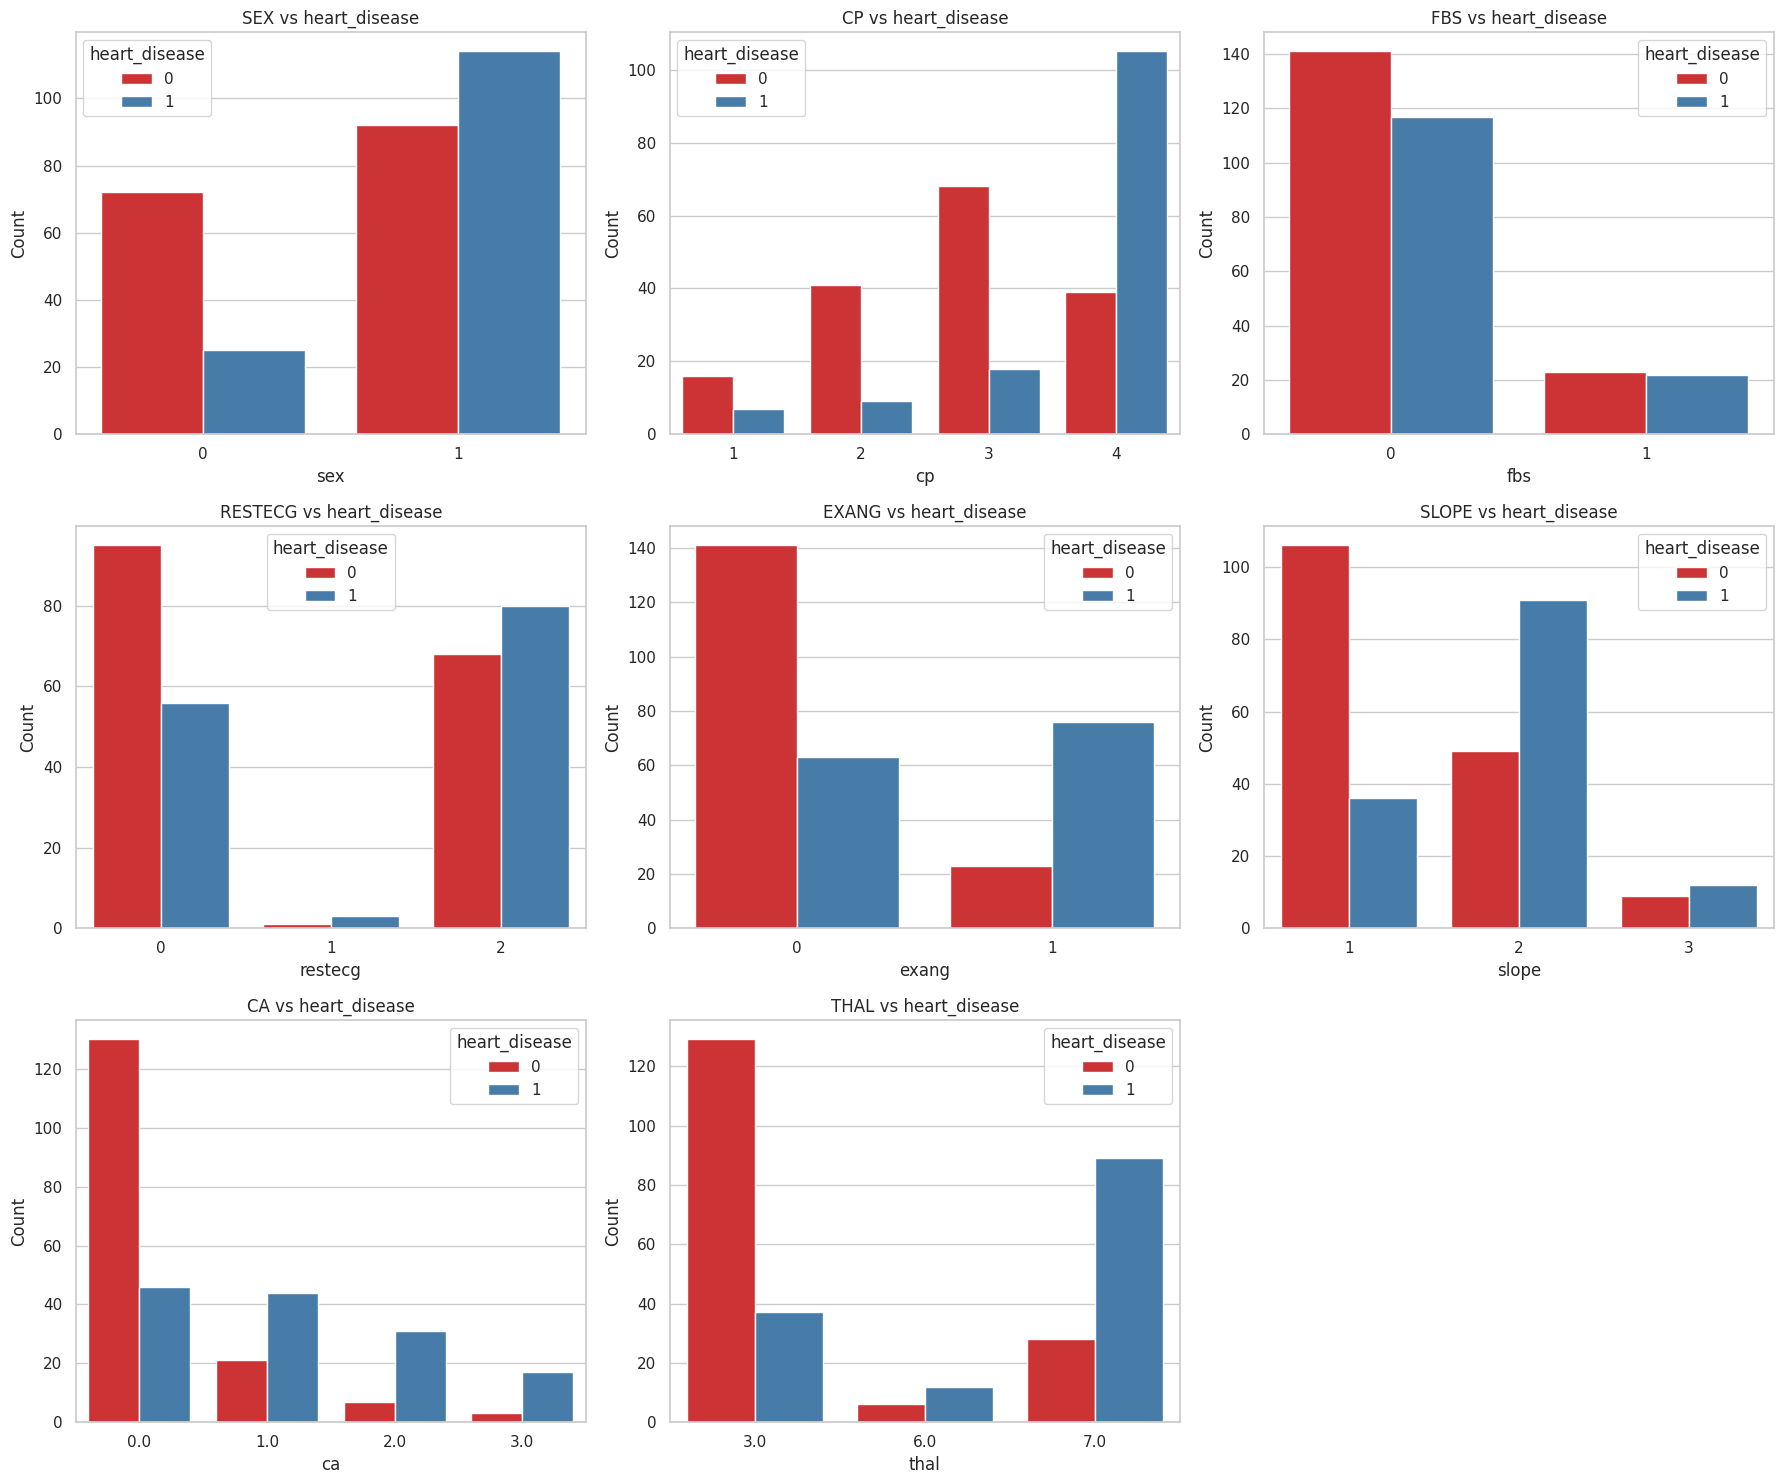

In [12]:
# Visulaize and identify the the categories that are associated with the elevated risk of heart disease.

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='heart_disease', palette='Set1', ax=axes[i])
    axes[i].set_title(f'{col.upper()} vs heart_disease')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

fig.delaxes(axes[8])
plt.tight_layout()
plt.show()


### 3. Numerical Features Analysis

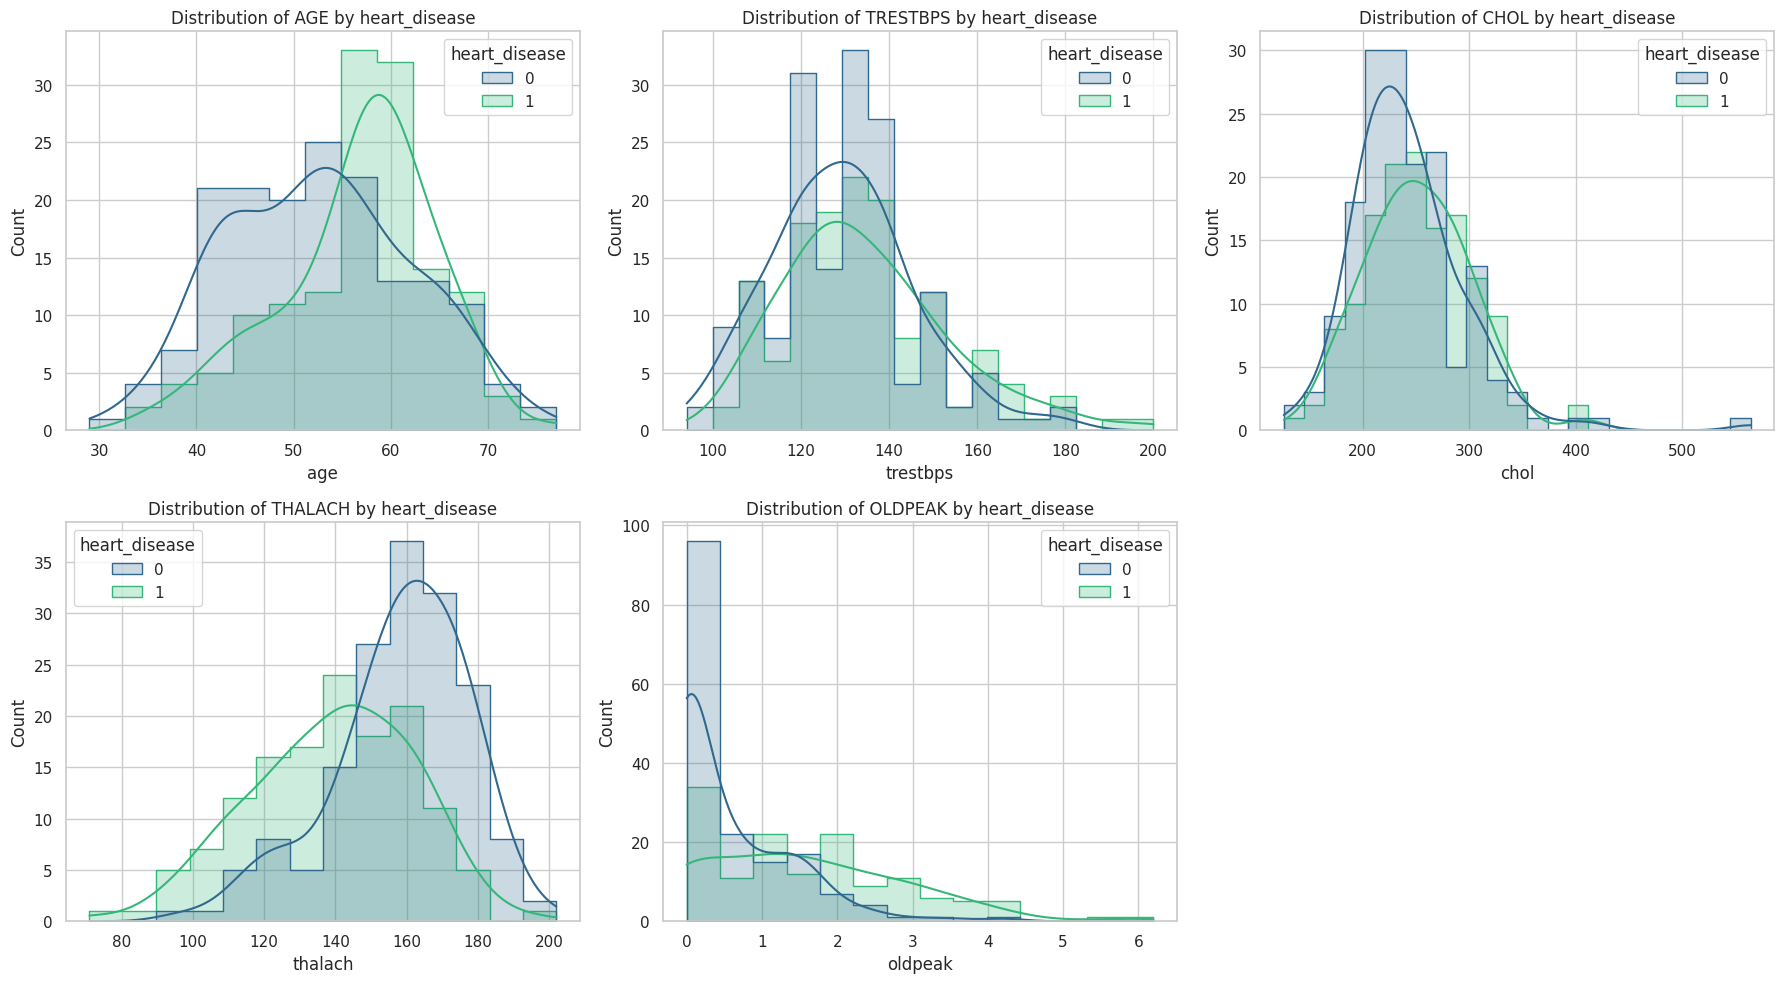

In [13]:
# Check how numerical data distribution differ between patients with and without heart disease
# List of continuous numerical features
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Plot histograms with KDE (Kernel Density Estimate) to see distributions
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='heart_disease', kde=True, palette='viridis', ax=axes[i], element='step')
    axes[i].set_title(f'Distribution of {col.upper()} by heart_disease')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()


### 4. Correlation Analysis

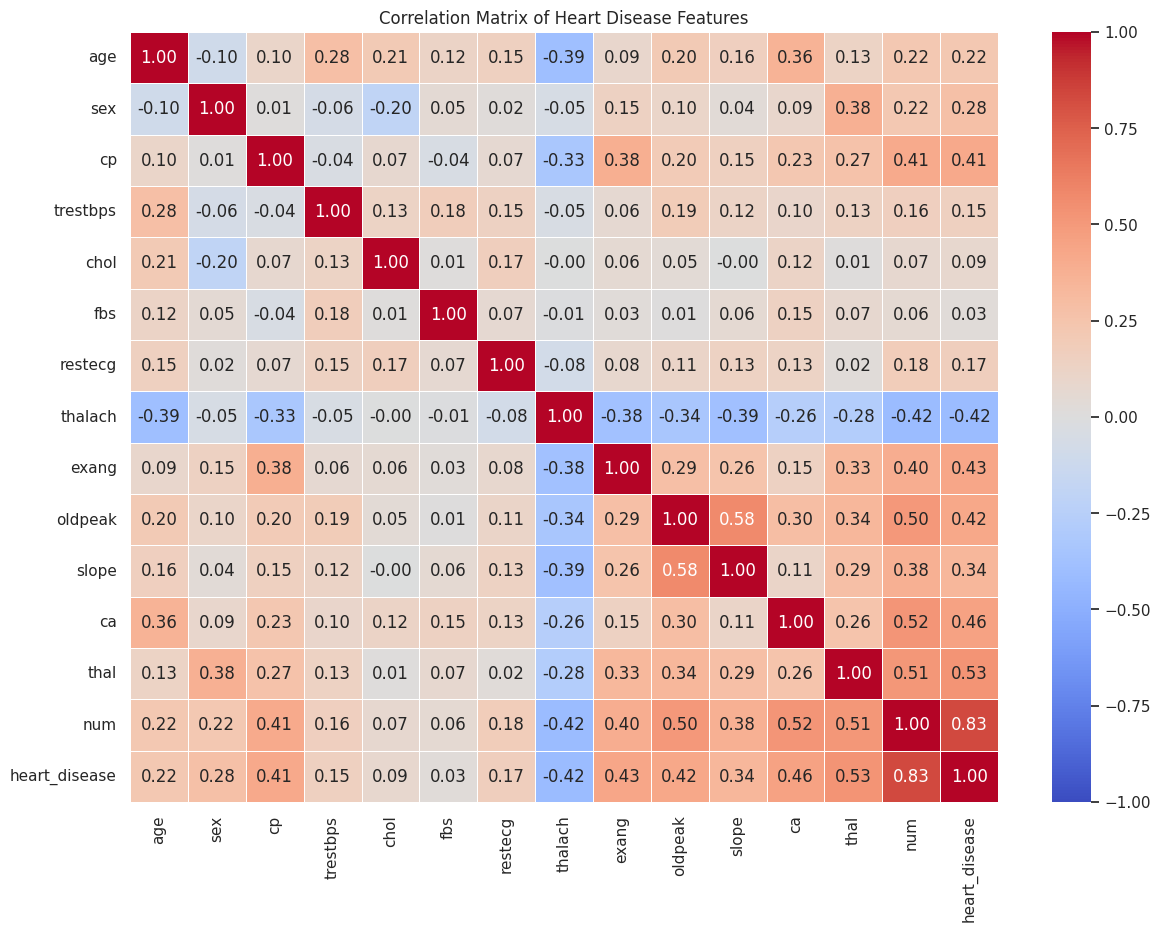

Feature Correlation with heart_disease:
heart_disease    1.000000
num              0.830081
thal             0.525689
ca               0.460442
exang            0.431894
oldpeak          0.424510
cp               0.414446
slope            0.339213
sex              0.276816
age              0.223120
restecg          0.169202
trestbps         0.150825
chol             0.085164
fbs              0.025264
thalach         -0.417167
Name: heart_disease, dtype: float64


In [14]:
# Check for Corelation between feature and target variables
# Calculate the Pearson correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Heart Disease Features')
plt.show()

# Display correlations specifically with the target variable, sorted
print("Feature Correlation with heart_disease:")
print(corr_matrix['heart_disease'].sort_values(ascending=False))


### 5. Outlier detection

/tmp/ipykernel_2894/1371392894.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, x='heart_disease', palette='pastel', ax=axes[i])
/tmp/ipykernel_2894/1371392894.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, x='heart_disease', palette='pastel', ax=axes[i])
/tmp/ipykernel_2894/1371392894.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, x='heart_disease', palette='pastel', ax=axes[i])
/tmp/ipykernel_2894/1371392894.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is depr

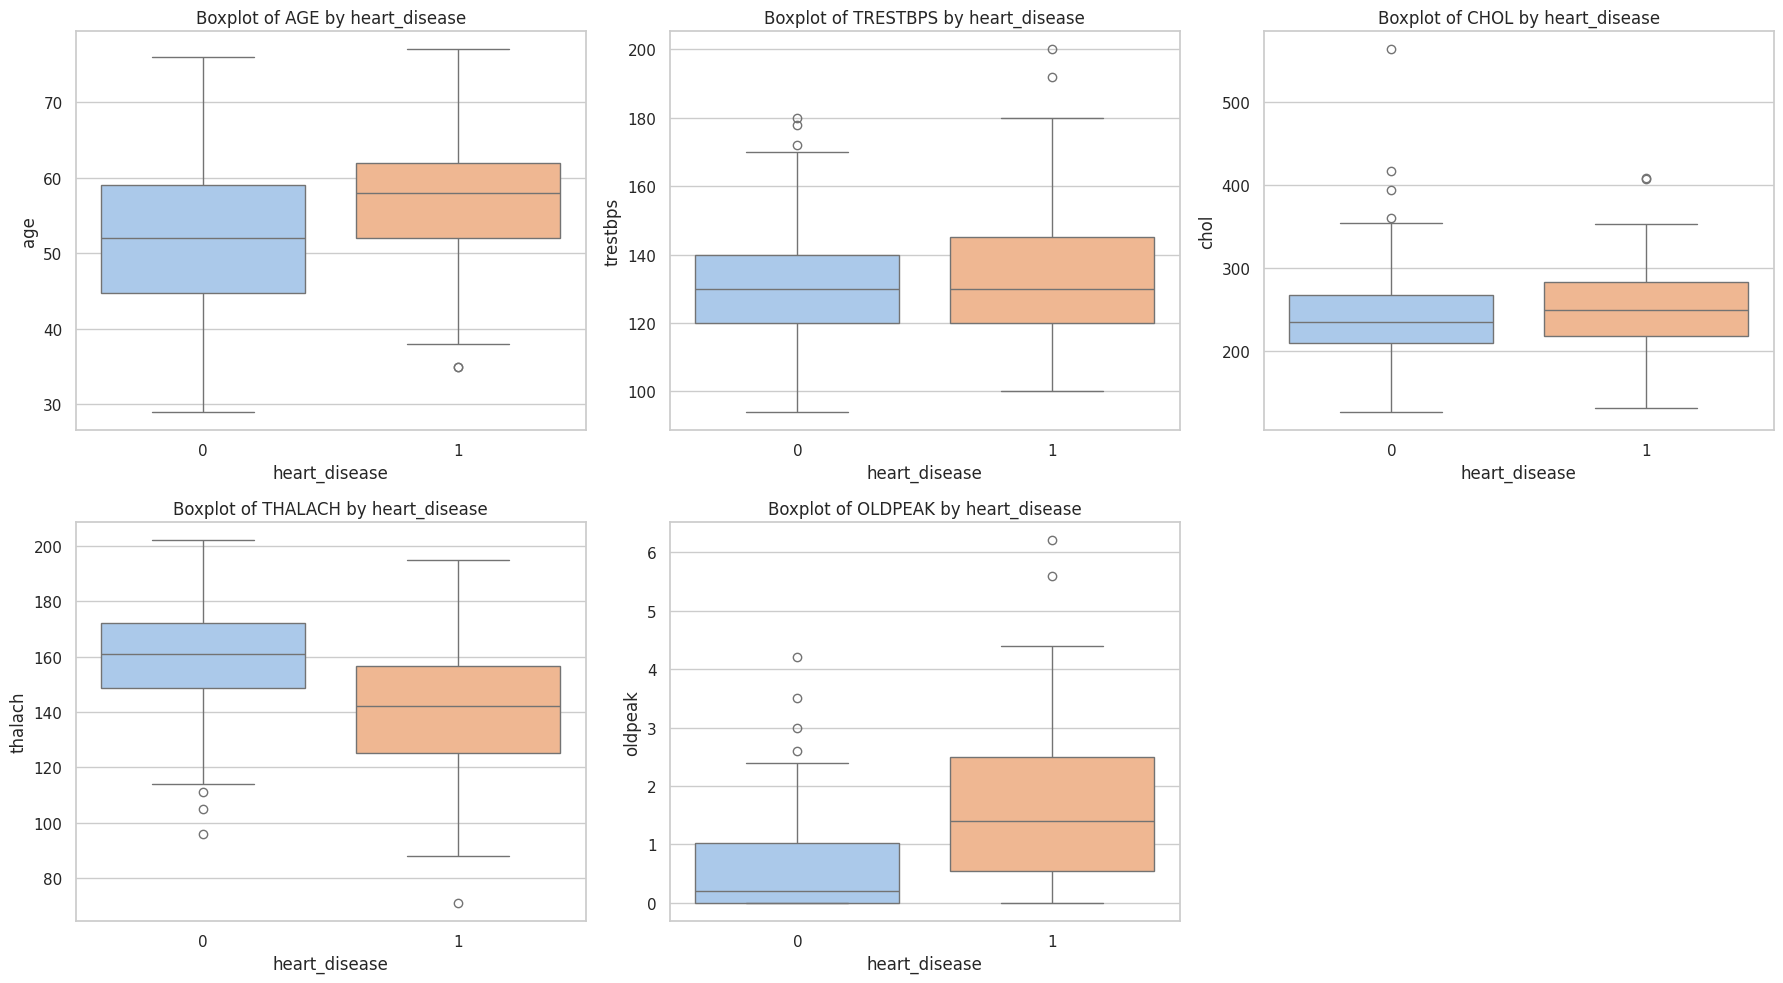

In [15]:
 # Check for Any outliers present in the data
 # Boxplots for numerical features to identify outliers
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, x='heart_disease', palette='pastel', ax=axes[i])
    axes[i].set_title(f'Boxplot of {col.upper()} by heart_disease')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()


# Section 3: Feature Engineering

In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Handle Missing Values
# The EDA showed 'ca' has 4 missing values and 'thal' has 2.
# We use the median/mode since these are discrete/categorical features.
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# 2. Target Variable Transformation
# The target 'num' ranges from 0 to 4. For standard prediction,
# it is highly recommended to binarize this (0: No disease, 1: Disease present).
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop('num', axis=1)

# 3. Categorical Encoding (One-Hot Encoding)
# 'cp', 'restecg', 'slope', and 'thal' are categorical features represented by integers.
# Leaving them as integers tricks the model into thinking they have sequential weight.
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Feature Scaling
# Continuous variables have vastly different ranges (e.g., chol up to 564, oldpeak up to 6.2).
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

# Displaying updated details
print("Updated Shape:", df.shape)
display(df.head())

Updated Shape: (303, 20)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,heart_disease,target,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,thal_6.0,thal_7.0
0,0.948726,1,0.757525,-0.264900,1,0.017197,0,1.087338,0.0,0,0,False,False,False,False,True,False,True,True,False
1,1.392002,1,1.611220,0.760415,0,-1.821905,1,0.397182,3.0,1,1,False,False,True,False,True,True,False,False,False
2,1.392002,1,-0.665300,-0.342283,0,-0.902354,1,1.346147,2.0,1,1,False,False,True,False,True,True,False,False,True
3,-1.932564,1,-0.096170,0.063974,0,1.637359,0,2.122573,0.0,0,0,False,True,False,False,False,False,True,False,False
4,-1.489288,0,-0.096170,-0.825922,0,0.980537,0,0.310912,0.0,0,0,True,False,False,False,True,False,False,False,False


# Section 4: Initial Model Development

In [ ]:
import pandas as pd
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split

# 1. Automatically convert X and y into long format
df_raw = df.copy()
df_raw['patient_id'] = df_raw.index

# Melt wide columns into 3 interaction columns: patient_id, item_id, rating
df_surprise = df_raw.melt(id_vars=['patient_id'], var_name='item_id', value_name='rating').dropna()

# 2. Convert to Surprise Dataset
min_val = df_surprise['rating'].min()
max_val = df_surprise['rating'].max()
reader = Reader(rating_scale=(min_val, max_val))

data_surprise = Dataset.load_from_df(df_surprise[['patient_id', 'item_id', 'rating']], reader)

# 3. Train-test split
trainset, testset = train_test_split(data_surprise, test_size=0.25, random_state=42)

# 4. Train SVD model
algo = SVD(random_state=42)
algo.fit(trainset)

# 5. Predict and evaluate
predictions = algo.test(testset)
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

# Section 5: Initial Model Evaluation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Collect the test-set predictions from Section 4 into a DataFrame
pred_df = pd.DataFrame(
    [(p.uid, p.iid, p.r_ui, p.est) for p in predictions],
    columns=['patient_id', 'item_id', 'actual', 'predicted']
)
pred_df['error'] = pred_df['predicted'] - pred_df['actual']

y_true = pred_df['actual'].to_numpy()
y_pred = pred_df['predicted'].to_numpy()

# Core metrics
svd_mse  = mean_squared_error(y_true, y_pred)
svd_rmse = np.sqrt(svd_mse)
svd_mae  = mean_absolute_error(y_true, y_pred)
svd_r2   = r2_score(y_true, y_pred)

# Sanity check: must agree with the values Surprise reported in Section 4
assert np.isclose(svd_rmse, accuracy.rmse(predictions, verbose=False))
assert np.isclose(svd_mae,  accuracy.mae(predictions,  verbose=False))

rating_range = max_val - min_val          # scale used by the Surprise Reader

metrics_df = pd.DataFrame({
    'Metric': [
        'Test predictions (n)',
        'RMSE',
        'MAE',
        'MSE',
        'R²',
        'Mean error (bias = predicted - actual)',
        'RMSE / rating range',
        'RMSE / std of actual values',
    ],
    'Value': [
        f'{len(pred_df):,}',
        f'{svd_rmse:,.4f}',
        f'{svd_mae:,.4f}',
        f'{svd_mse:,.2f}',
        f'{svd_r2:,.4f}',
        f"{pred_df['error'].mean():,.4f}",
        f'{svd_rmse / rating_range:,.4f}',
        f'{svd_rmse / y_true.std():,.4f}',
    ]
})
display(metrics_df)

# Model health checks
print('\nModel health checks')
print('  Any NaN in learned patient factors :', bool(np.isnan(algo.pu).any()))
print('  Unique predicted values            :', pred_df['predicted'].nunique())
print(f'  Predictions equal to scale max ({max_val:g}): '
      f"{(pred_df['predicted'] == max_val).mean():.1%}")

In [ ]:
# Baselines built from the training set only (no test-set leakage)
train_ratings = pd.DataFrame(
    [(trainset.to_raw_iid(i), r) for (_, i, r) in trainset.all_ratings()],
    columns=['item_id', 'rating']
)
global_mean = train_ratings['rating'].mean()
item_means  = train_ratings.groupby('item_id')['rating'].mean()

model_preds = {
    'SVD (initial model)':        y_pred,
    'Baseline: global mean':      np.full(len(y_true), global_mean),
    'Baseline: per-feature mean': pred_df['item_id'].map(item_means).to_numpy(),
}

comparison = pd.DataFrame({
    name: {
        'RMSE': np.sqrt(mean_squared_error(y_true, p)),
        'MAE':  mean_absolute_error(y_true, p),
        'R²':   r2_score(y_true, p),
    }
    for name, p in model_preds.items()
}).T
display(comparison.round(4))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Actual vs predicted
axes[0].scatter(y_true, y_pred, alpha=0.4, s=18)
lims = [0, max(y_true.max(), y_pred.max()) * 1.05]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual value')
axes[0].set_ylabel('Predicted value')
axes[0].set_title('SVD: Actual vs Predicted (test set)')
axes[0].legend()

# (b) RMSE and (c) MAE per model
for ax, metric in zip(axes[1:], ['RMSE', 'MAE']):
    bars = ax.bar(comparison.index, comparison[metric],
                  color=['#d62728', '#7f7f7f', '#1f77b4'])
    ax.bar_label(bars, fmt='%.1f', padding=3)
    ax.set_title(f'{metric} by model (lower is better)')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
pred_df['abs_error'] = pred_df['error'].abs()
pred_df['sq_error']  = pred_df['error'] ** 2
pred_df['item_mean_sq_error'] = (pred_df['item_id'].map(item_means) - pred_df['actual']) ** 2

g = pred_df.groupby('item_id')
per_feature = pd.DataFrame({
    'n_test':            g.size(),
    'actual_mean':       g['actual'].mean(),
    'predicted_mean':    g['predicted'].mean(),
    'SVD_MAE':           g['abs_error'].mean(),
    'SVD_RMSE':          np.sqrt(g['sq_error'].mean()),
    'FeatureMean_RMSE':  np.sqrt(g['item_mean_sq_error'].mean()),
}).sort_values('actual_mean', ascending=False).round(2)

display(per_feature)

In [ ]:
# @title
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

num_df = pred_df[pred_df['item_id'] == 'num']
y_true_bin = (num_df['actual'] > 0).astype(int)
y_pred_bin = (num_df['predicted'] >= 0.5).astype(int)

prevalence = y_true_bin.mean()
cls_metrics = pd.DataFrame({
    'Metric': ['Test patients (n)', 'Disease prevalence', 'Accuracy',
               'Majority-class accuracy (reference)', 'Precision', 'Recall (sensitivity)',
               'F1 score', 'ROC-AUC'],
    'Value': [
        f'{len(num_df):,}',
        f'{prevalence:.4f}',
        f'{accuracy_score(y_true_bin, y_pred_bin):.4f}',
        f'{max(prevalence, 1 - prevalence):.4f}',
        f'{precision_score(y_true_bin, y_pred_bin, zero_division=0):.4f}',
        f'{recall_score(y_true_bin, y_pred_bin, zero_division=0):.4f}',
        f'{f1_score(y_true_bin, y_pred_bin, zero_division=0):.4f}',
        f'{roc_auc_score(y_true_bin, num_df["predicted"]):.4f}',
    ]
})
display(cls_metrics)

cm = pd.DataFrame(
    confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]),
    index=['Actual: No disease', 'Actual: Disease'],
    columns=['Predicted: No disease', 'Predicted: Disease']
)
display(cm)

## Section 6: Hyperparameter Tuning

In [ ]:
from surprise.model_selection import GridSearchCV

# Define parameter grid with expanded ranges
param_grid = {
    'n_epochs': [40, 50],
    'lr_all': [0.03, 0.06],
    'reg_all': [0.01, 0.04]
}

# Perform GridSearchCV
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data_surprise)

# Best RMSE score
print(f"Best RMSE score: {gs.best_score['rmse']:.4f}")
print(f"Best MAE score: {gs.best_score['mae']:.4f}")

# Best parameters
print("Best parameters:", gs.best_params['rmse'])

# Model Overhaul and Baseline metrics

In [ ]:
rfc = Random